# 01 - Burgers' Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t + u u_x = \nu u_{xx}$, $\nu = 0.01/\pi$

**IC:** $u(x,0) = -\sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 64, 64, 64, 64, 64, 1]` | **Epochs:** 10000

---
### Experiments
1. Vanilla PINN - clean dense data
2. Vanilla PINN - noisy sparse data (ε=0.1, N_ic=20)
3. AC-PINN - clean dense data
4. AC-PINN - noisy sparse data (ε=0.1, N_ic=20)

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    BurgersFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE      = 'burgers'
LAYERS   = [2, 64, 64, 64, 64, 64, 1]
EPOCHS   = 10000
PDE_PARAMS = {'nu': 0.01/np.pi}
RESULTS  = '../results/burgers/'
FIGURES  = '../figures/burgers/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, **PDE_PARAMS)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

BurgersFDM solved in 0.6440s


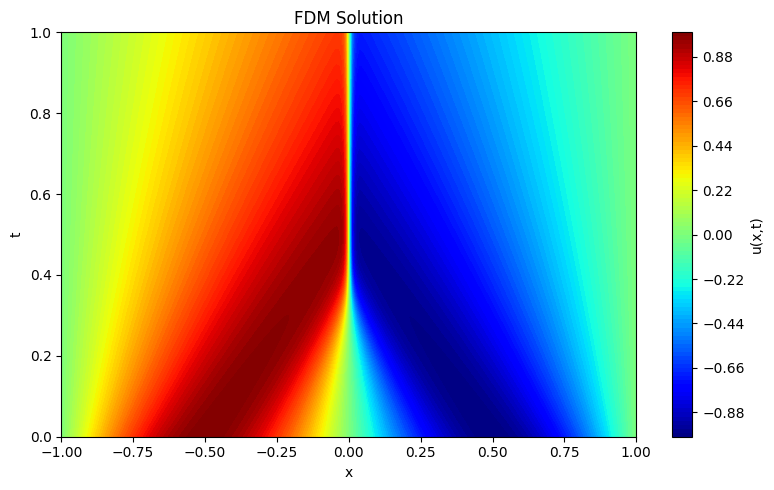

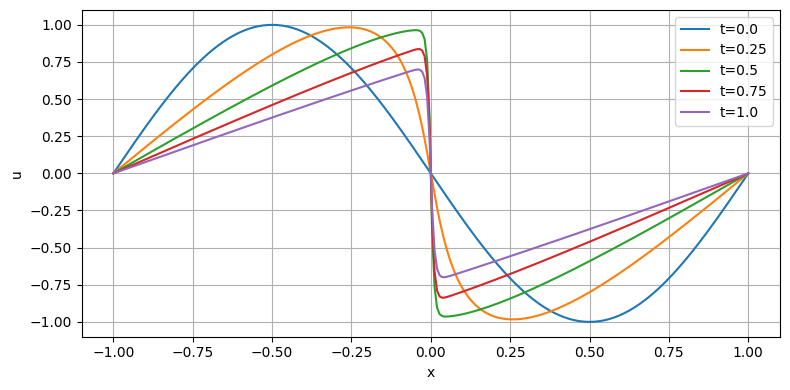

FDM runtime: 0.6440s


In [2]:
fdm = BurgersFDM(nx=256, nt=2000, nu=0.01/np.pi)
fdm.solve()
fdm.plot_solution()
fdm.plot_time_slices()
print(f'FDM runtime: {fdm.runtime:.4f}s')

## Section 2 - Data Conditions

In [3]:
# Clean dense
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
# Noisy sparse
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)

print('Data conditions ready')
print(f'  Clean dense  : N_ic={data_clean_dense["x_ic"].shape[0]}')
print(f'  Noisy sparse : N_ic={data_noisy_sparse["x_ic"].shape[0]}, eps=0.1')

Data conditions ready
  Clean dense  : N_ic=1000
  Noisy sparse : N_ic=20, eps=0.1


## Section 3 - Experiment 1: Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Burgers | Vanilla Clean | Epoch     0/10000] Total: 1.283686 | IC: 0.621613 | BC: 0.098811 | PDE: 0.112652


[Burgers | Vanilla Clean | Epoch  1000/10000] Total: 0.109272 | IC: 0.093555 | BC: 0.000598 | PDE: 0.003024


[Burgers | Vanilla Clean | Epoch  2000/10000] Total: 0.072494 | IC: 0.056626 | BC: 0.000417 | PDE: 0.003090


[Burgers | Vanilla Clean | Epoch  3000/10000] Total: 0.252398 | IC: 0.151512 | BC: 0.003746 | PDE: 0.019428


...

[Burgers | Vanilla Clean | Epoch  6000/10000] Total: 0.009041 | IC: 0.006959 | BC: 0.000016 | PDE: 0.000413


[Burgers | Vanilla Clean | Epoch  7000/10000] Total: 0.005409 | IC: 0.003954 | BC: 0.000009 | PDE: 0.000289


[Burgers | Vanilla Clean | Epoch  8000/10000] Total: 0.002402 | IC: 0.001563 | BC: 0.000006 | PDE: 0.000167


[Burgers | Vanilla Clean | Epoch  9000/10000] Total: 0.001797 | IC: 0.001158 | BC: 0.000004 | PDE: 0.000127



Training complete in 145.90s


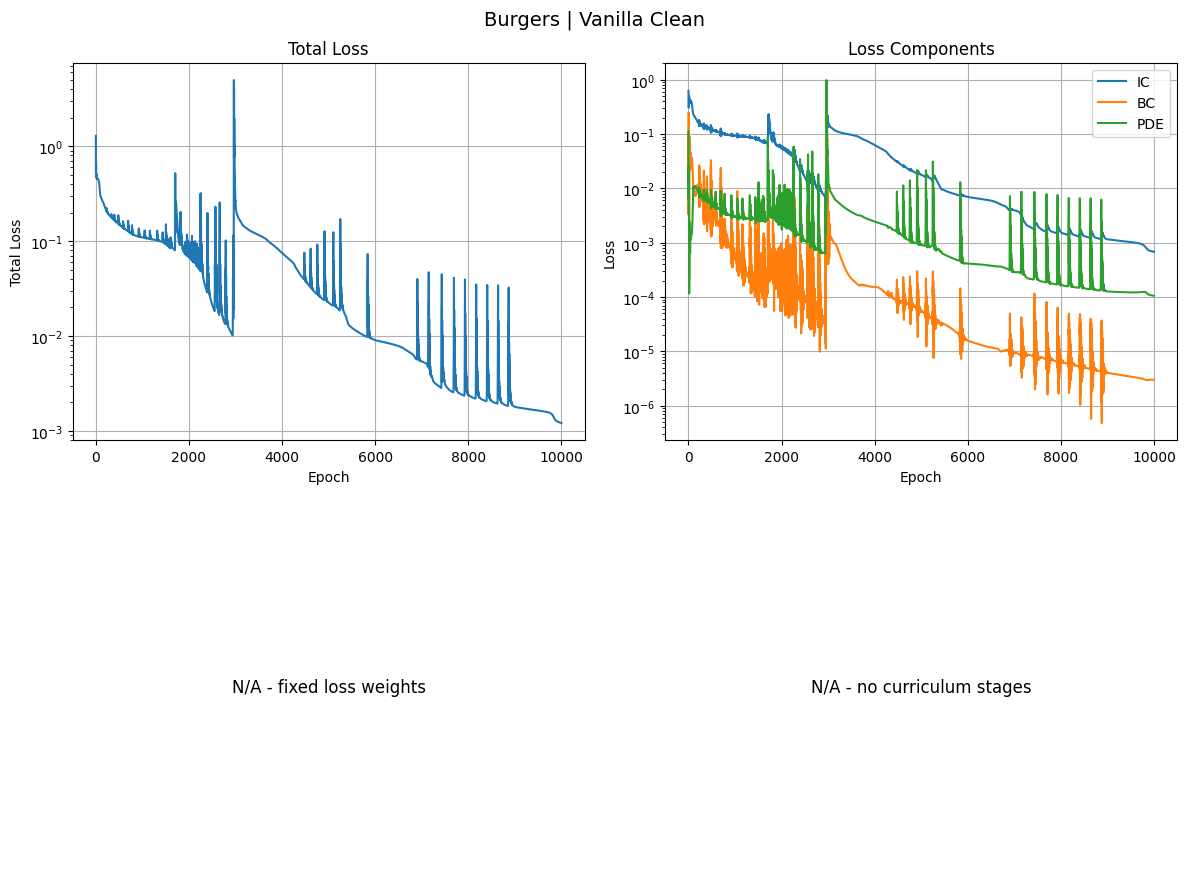

Saved: ../figures/burgers/vanilla_clean_training.png
Saved: ../figures/burgers/vanilla_clean_training.csv


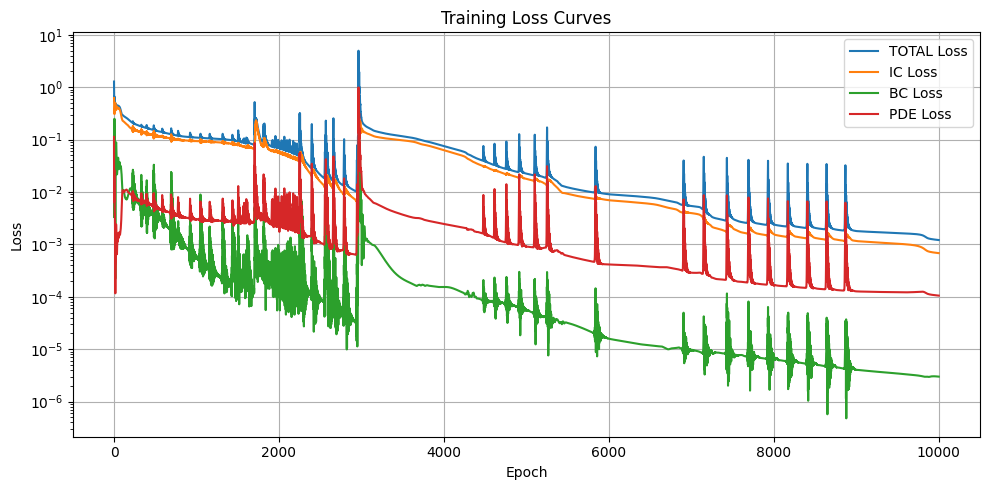

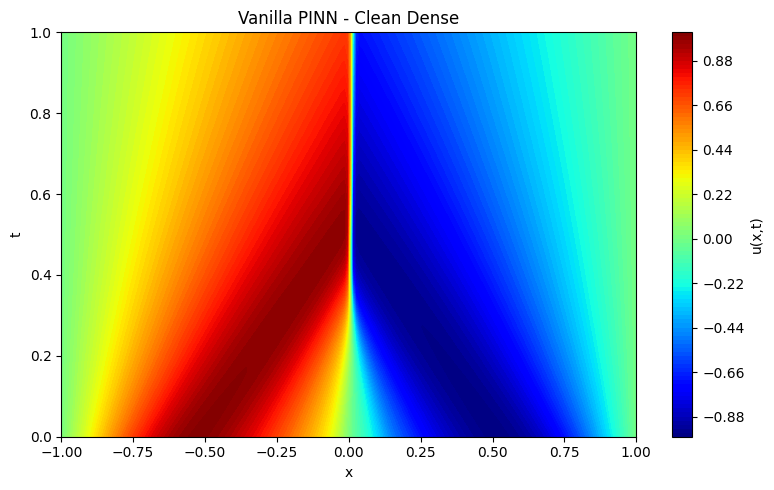

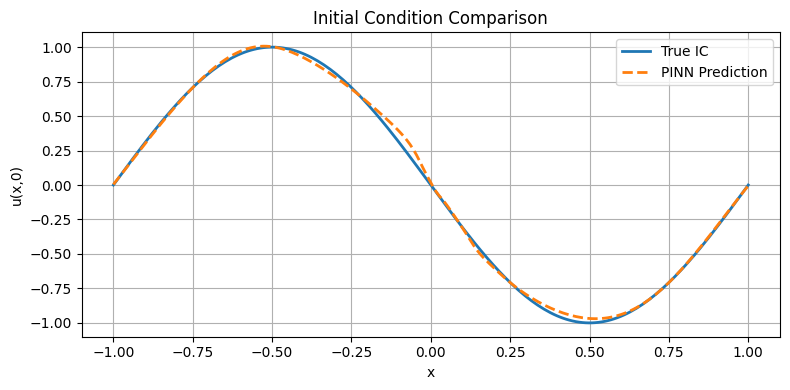

Saved: ../results/burgers/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Burgers | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS + 'vanilla_clean_history.npy')

## Section 4 - Experiment 2: Vanilla PINN, Noisy Sparse

[Burgers | Vanilla Noisy | Epoch     0/10000] Total: 0.785076 | IC: 0.332171 | BC: 0.103889 | PDE: 0.069803


[Burgers | Vanilla Noisy | Epoch  1000/10000] Total: 0.076621 | IC: 0.048412 | BC: 0.014756 | PDE: 0.002691


[Burgers | Vanilla Noisy | Epoch  2000/10000] Total: 0.038092 | IC: 0.020212 | BC: 0.013662 | PDE: 0.000844


[Burgers | Vanilla Noisy | Epoch  3000/10000] Total: 0.026976 | IC: 0.011251 | BC: 0.013336 | PDE: 0.000478


[Burgers | Vanilla Noisy | Epoch  4000/10000] Total: 0.031895 | IC: 0.008154 | BC: 0.013617 | PDE: 0.002025


...

[Burgers | Vanilla Noisy | Epoch  6000/10000] Total: 0.020909 | IC: 0.005478 | BC: 0.012693 | PDE: 0.000547


[Burgers | Vanilla Noisy | Epoch  7000/10000] Total: 0.018839 | IC: 0.004999 | BC: 0.012577 | PDE: 0.000253


[Burgers | Vanilla Noisy | Epoch  8000/10000] Total: 0.018834 | IC: 0.004639 | BC: 0.012449 | PDE: 0.000349


[Burgers | Vanilla Noisy | Epoch  9000/10000] Total: 0.017823 | IC: 0.004291 | BC: 0.012168 | PDE: 0.000273



Training complete in 129.70s


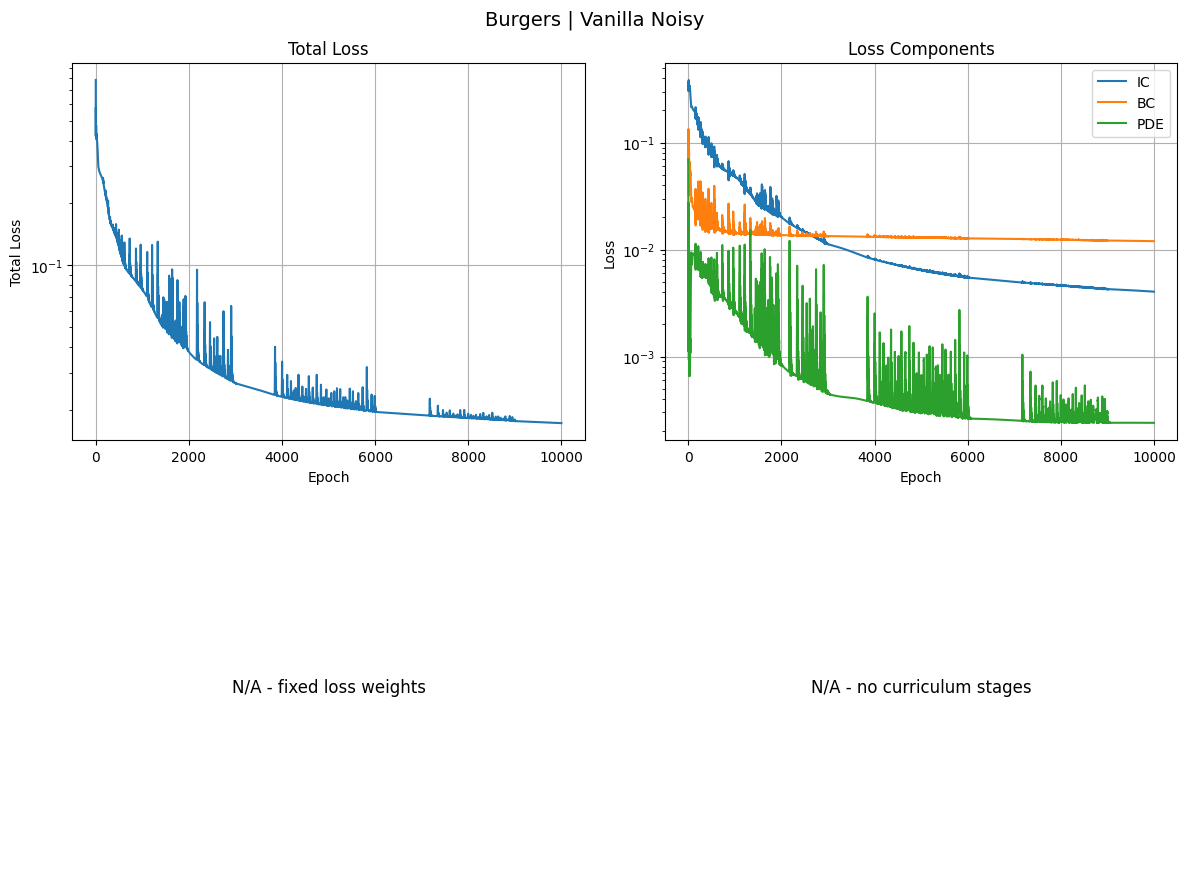

Saved: ../figures/burgers/vanilla_noisy_training.png
Saved: ../figures/burgers/vanilla_noisy_training.csv


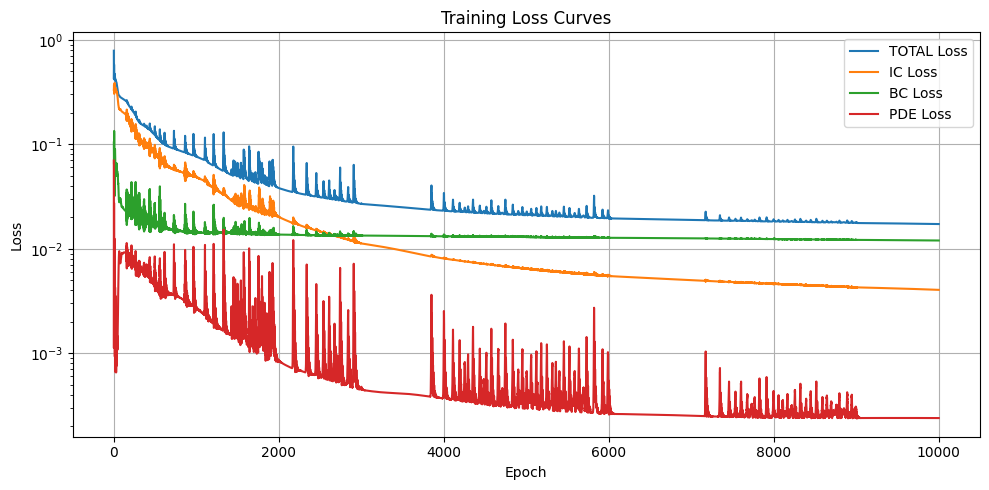

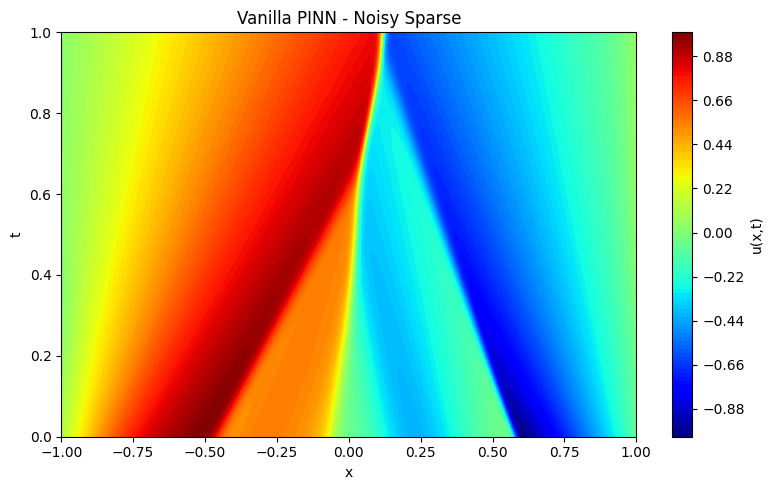

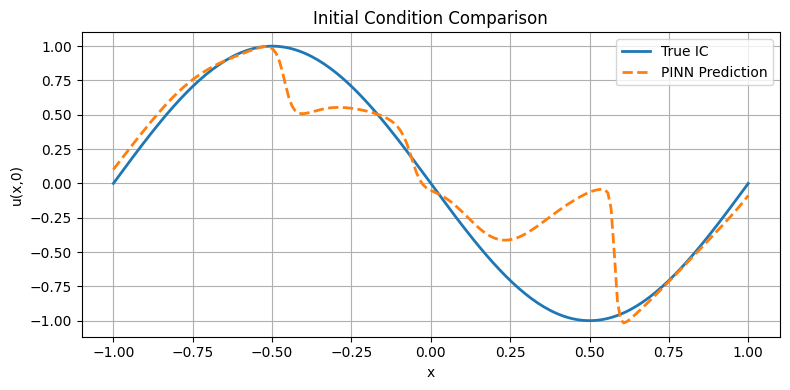

Saved: ../results/burgers/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                            lambda_ic=1.0, lambda_bc=1.0, lambda_pde=5.0)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Burgers | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
vanilla_noisy.plot_initial_condition_comparison(gen)
save_history(h_vn, RESULTS + 'vanilla_noisy_history.npy')

## Section 5 - Experiment 3: AC-PINN, Clean Dense

[Burgers | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 1.392344 | IC: 0.670169 | BC: 0.148784 | PDE: 0.114678 | lam=(1.00,1.00,5.00)


[Burgers | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.006756 | IC: 0.000590 | BC: 0.000226 | PDE: 0.000388 | lam=(4.34,1.38,10.00)


[Burgers | AC-PINN Clean | Epoch  2000/10000] Stage 1/4 | Total: 0.000637 | IC: 0.000016 | BC: 0.000012 | PDE: 0.000047 | lam=(10.00,1.15,10.00)


[Burgers | AC-PINN Clean | Epoch  3000/10000] Stage 2/4 | Total: 0.000200 | IC: 0.000005 | BC: 0.000002 | PDE: 0.000093 | lam=(10.00,3.09,1.51)


[Burgers | AC-PINN Clean | Epoch  4000/10000] Stage 2/4 | Total: 0.000205 | IC: 0.000004 | BC: 0.000002 | PDE: 0.000067 | lam=(10.00,1.79,2.43)


...

[Burgers | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.006489 | IC: 0.002505 | BC: 0.000141 | PDE: 0.000307 | lam=(2.54,0.14,0.31)


[Burgers | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000441 | IC: 0.000025 | BC: 0.000022 | PDE: 0.000179 | lam=(0.33,0.29,2.38)


[Burgers | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.562766 | IC: 0.190817 | BC: 0.002445 | PDE: 0.000956 | lam=(2.95,0.10,0.10)


[Burgers | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.662579 | IC: 0.000849 | BC: 0.000677 | PDE: 0.222325 | lam=(0.10,0.10,2.98)



AC-PINN training complete in 158.78s


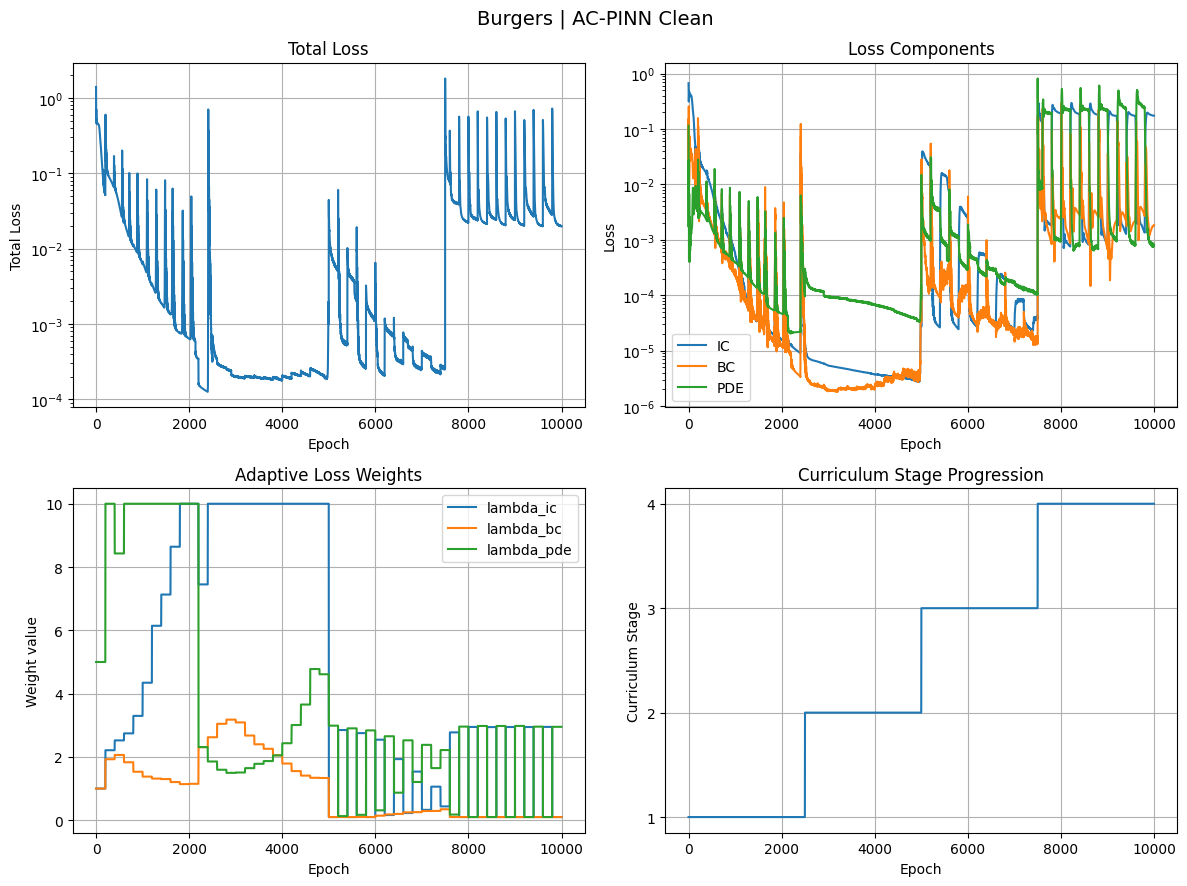

Saved: ../figures/burgers/acpinn_clean_training.png
Saved: ../figures/burgers/acpinn_clean_training.csv


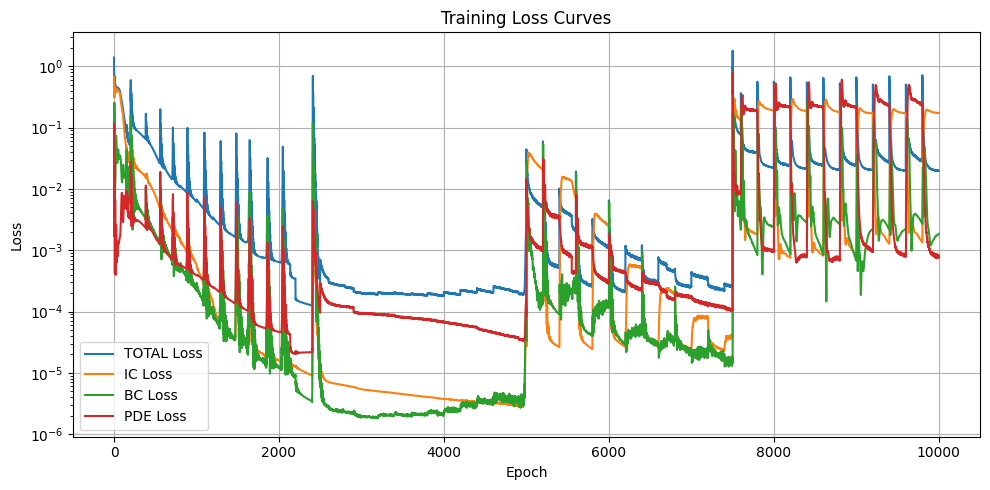

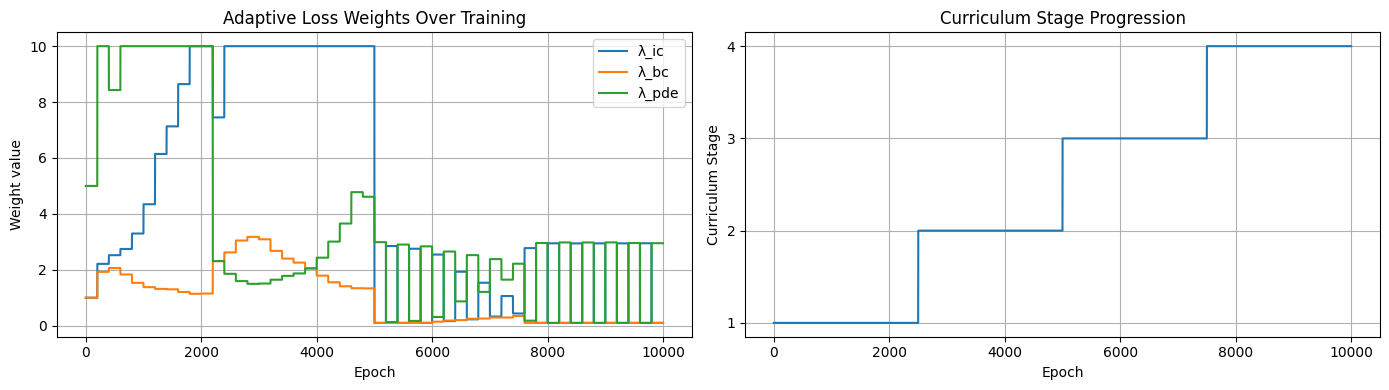

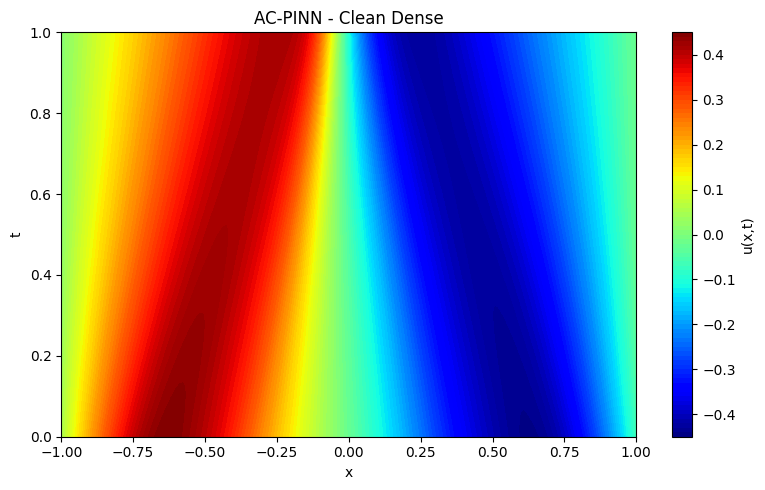

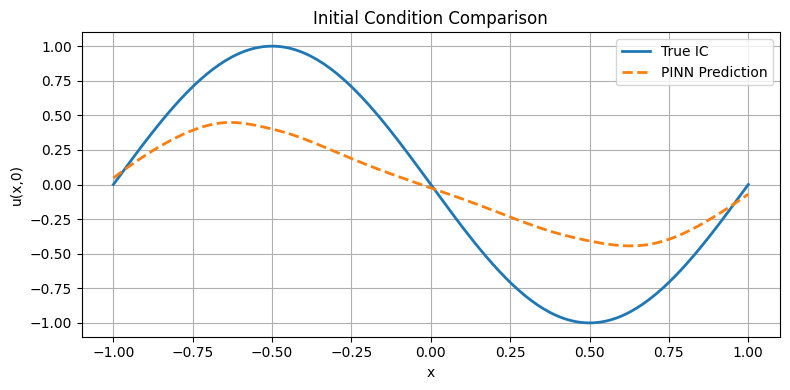

Saved: ../results/burgers/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Burgers | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
ac_clean.plot_initial_condition_comparison(gen)
save_history(h_ac, RESULTS + 'ac_clean_history.npy')

## Section 6 - Experiment 4: AC-PINN, Noisy Sparse

[Burgers | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 0.930336 | IC: 0.669363 | BC: 0.138638 | PDE: 0.024467 | lam=(1.00,1.00,5.00)


[Burgers | AC-PINN Noisy | Epoch  1000/10000] Stage 1/4 | Total: 0.085406 | IC: 0.005495 | BC: 0.011705 | PDE: 0.001030 | lam=(7.47,3.64,1.69)


[Burgers | AC-PINN Noisy | Epoch  2000/10000] Stage 1/4 | Total: 0.058091 | IC: 0.005181 | BC: 0.010511 | PDE: 0.000037 | lam=(8.80,1.15,10.00)


[Burgers | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.050439 | IC: 0.005068 | BC: 0.010115 | PDE: 0.000304 | lam=(6.91,1.23,10.00)


[Burgers | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.034867 | IC: 0.005072 | BC: 0.009750 | PDE: 0.000138 | lam=(3.79,1.46,10.00)


...

[Burgers | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.020524 | IC: 0.005094 | BC: 0.008938 | PDE: 0.002057 | lam=(0.95,1.67,0.38)


[Burgers | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.019550 | IC: 0.005021 | BC: 0.008490 | PDE: 0.002088 | lam=(0.97,1.63,0.40)


[Burgers | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.115760 | IC: 0.020030 | BC: 0.013978 | PDE: 0.052277 | lam=(0.70,0.49,1.82)


[Burgers | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.205987 | IC: 0.080105 | BC: 0.014840 | PDE: 0.001802 | lam=(2.48,0.46,0.10)



AC-PINN training complete in 143.00s


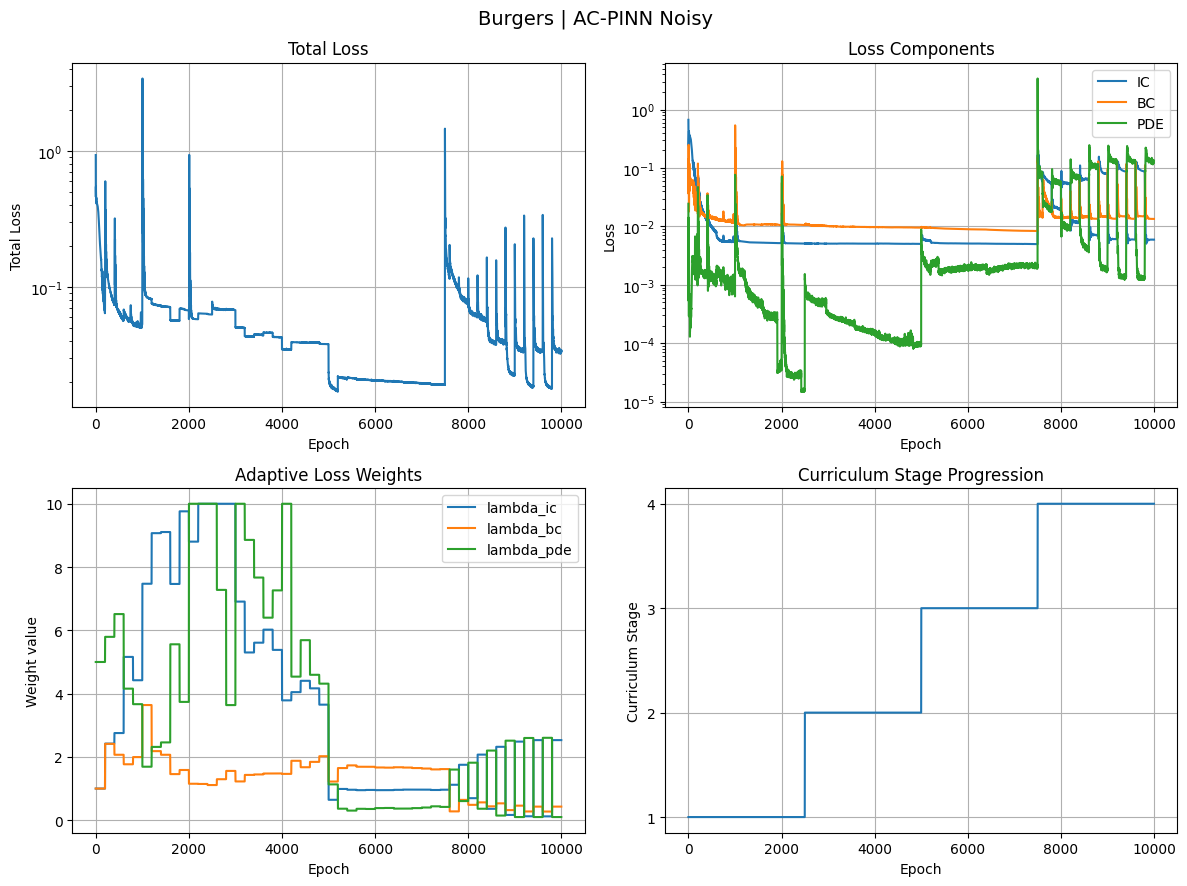

Saved: ../figures/burgers/acpinn_noisy_training.png
Saved: ../figures/burgers/acpinn_noisy_training.csv


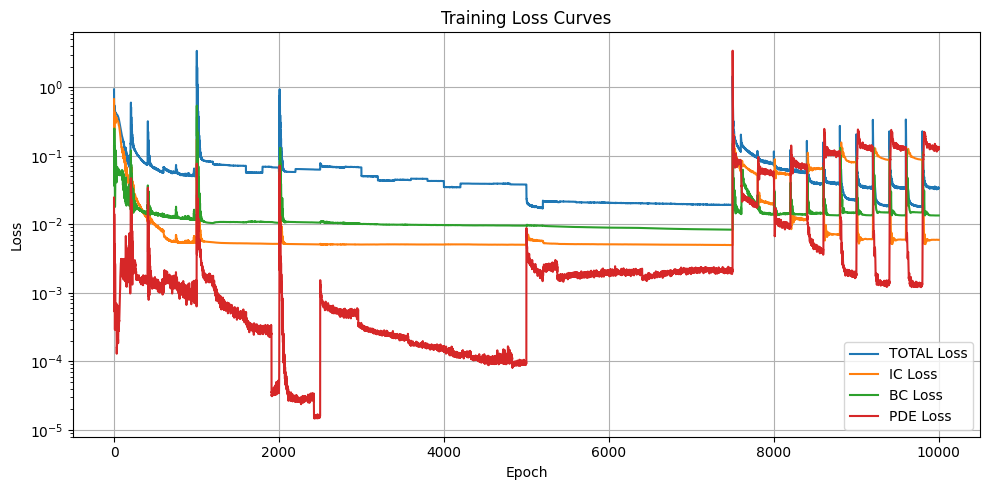

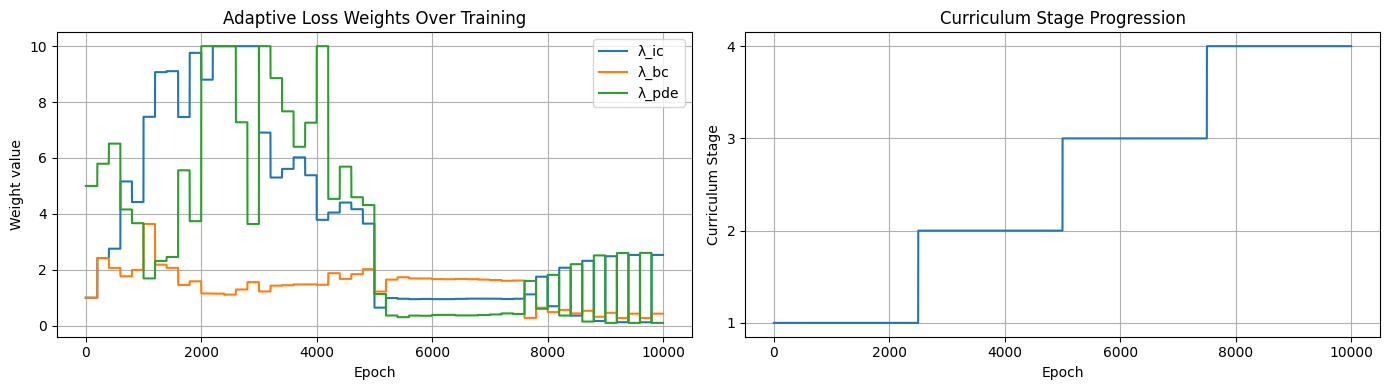

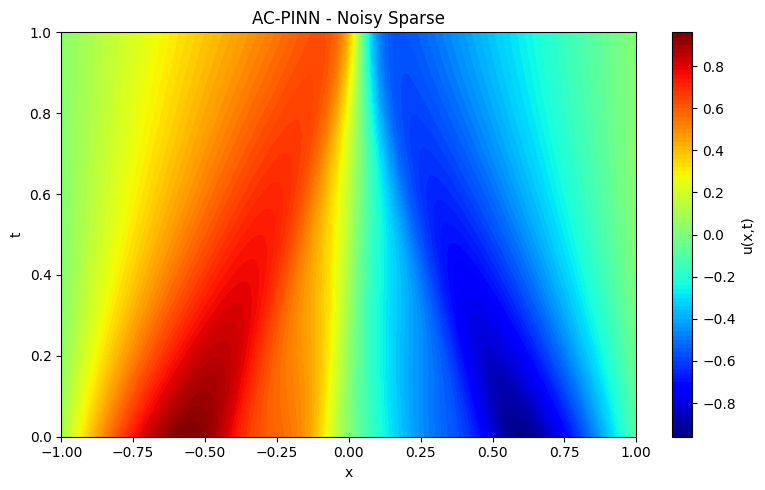

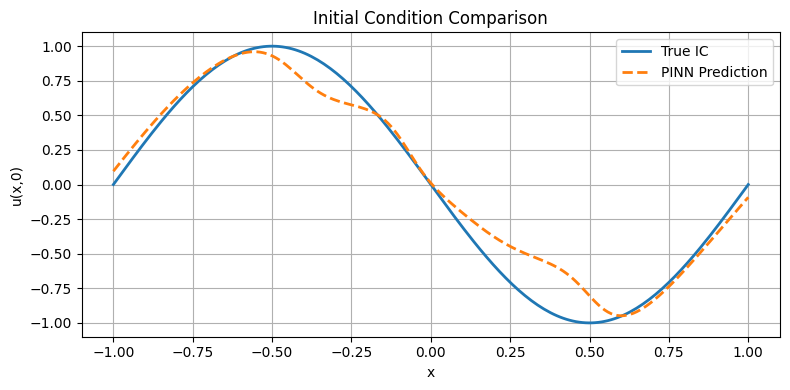

Saved: ../results/burgers/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS,
                         weight_strategy='both', N_pool=20000, resample_every=500)
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Burgers | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Burgers | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
ac_noisy.plot_initial_condition_comparison(gen)
save_history(h_an, RESULTS + 'ac_noisy_history.npy')

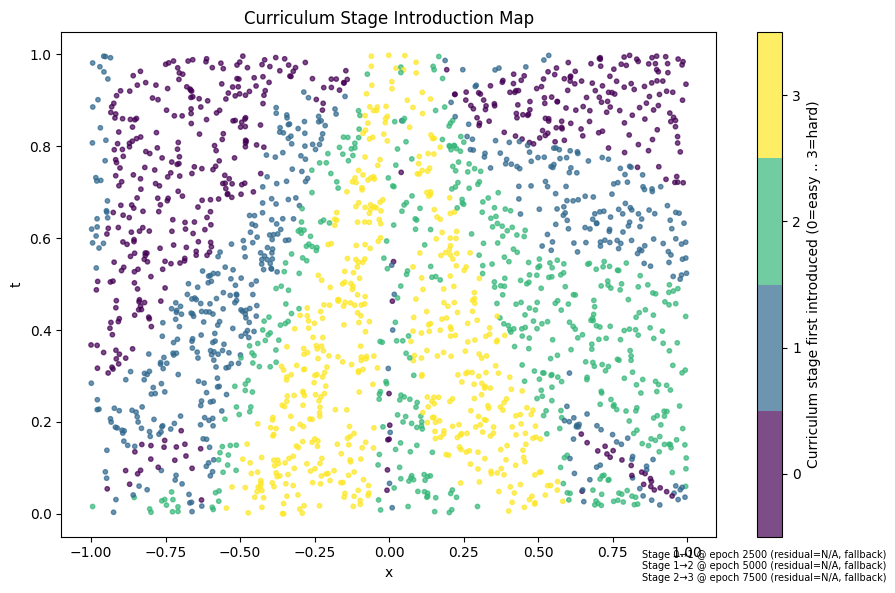

Saved: ../figures/burgers/curriculum_stages_noisy.png


In [8]:
ac_noisy.plot_curriculum_stages(
    h_an, data_noisy_sparse, FIGURES+'curriculum_stages_noisy.png'
)


## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.089024   0.851324   0.012810   0.054141
  Vanilla (noisy)             0.499707   1.725614   0.141774   0.303904
  AC-PINN (clean)             0.610625   0.963661   0.270323   0.371360
  AC-PINN (noisy)             0.380963   0.965890   0.126298   0.231688


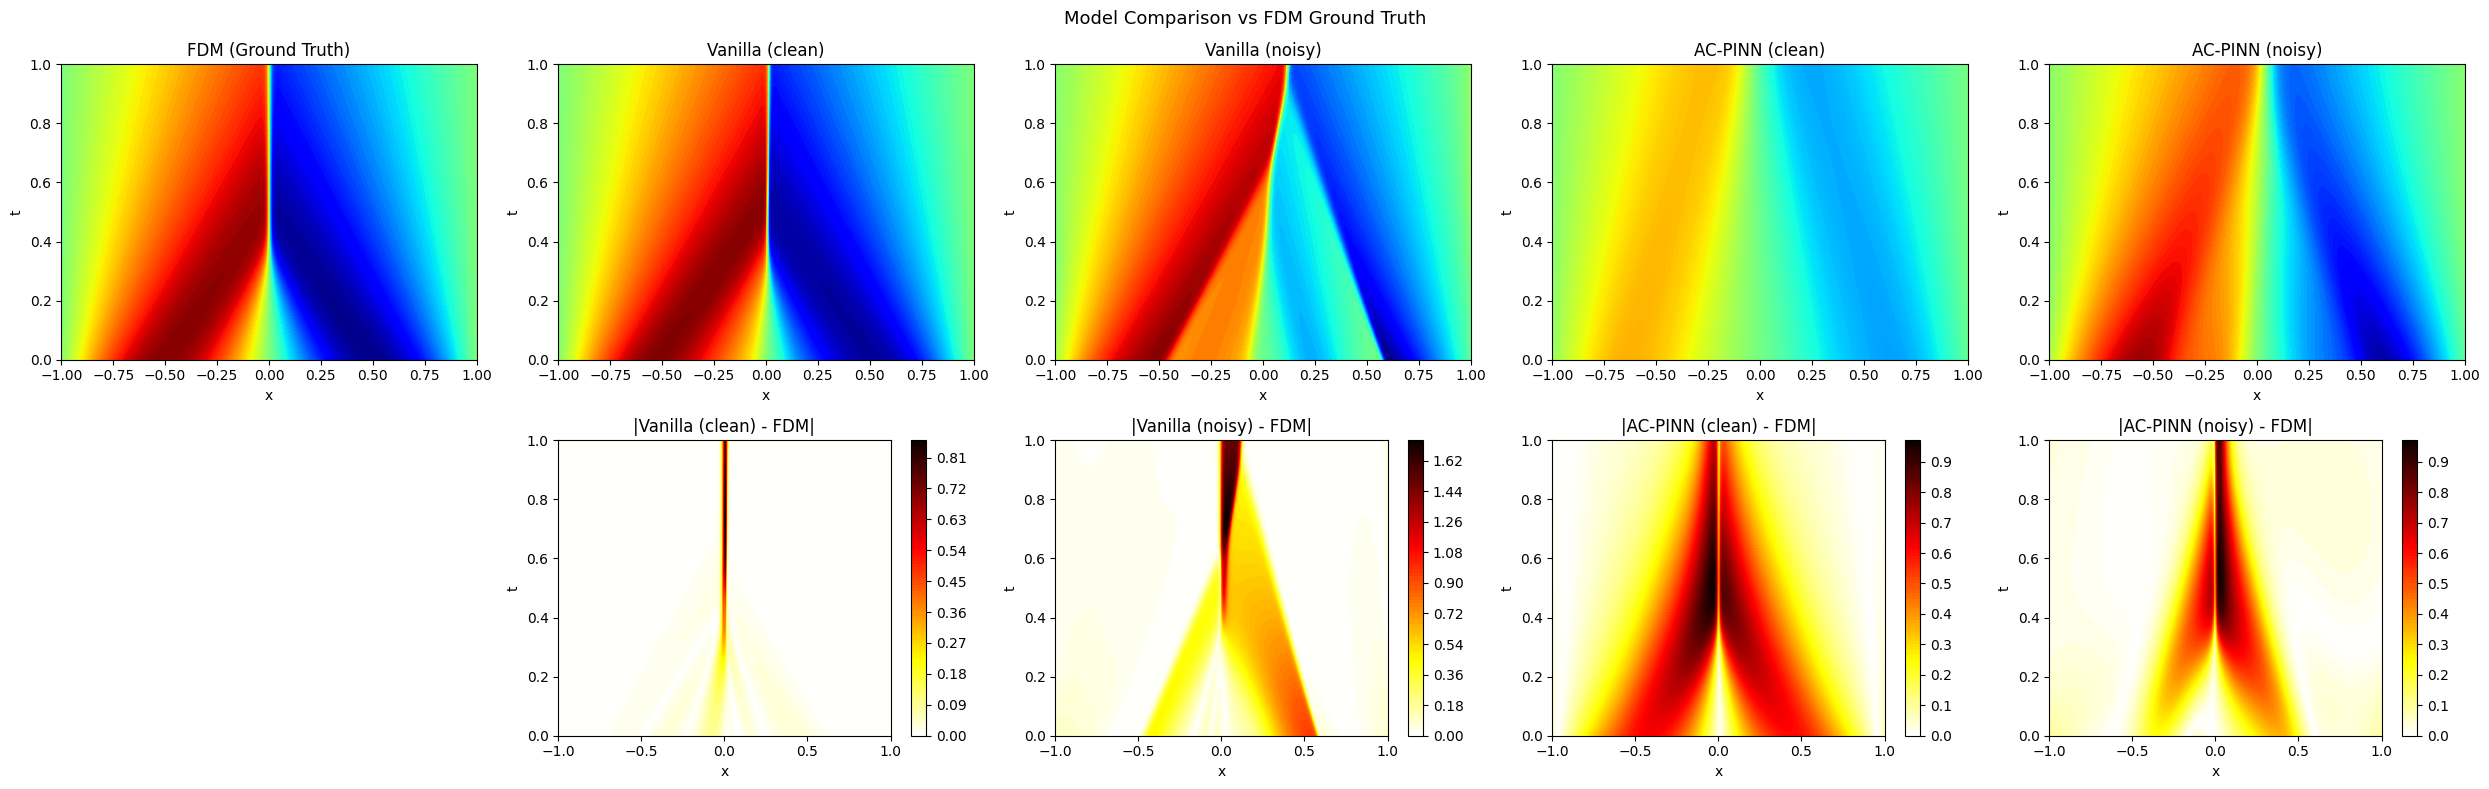

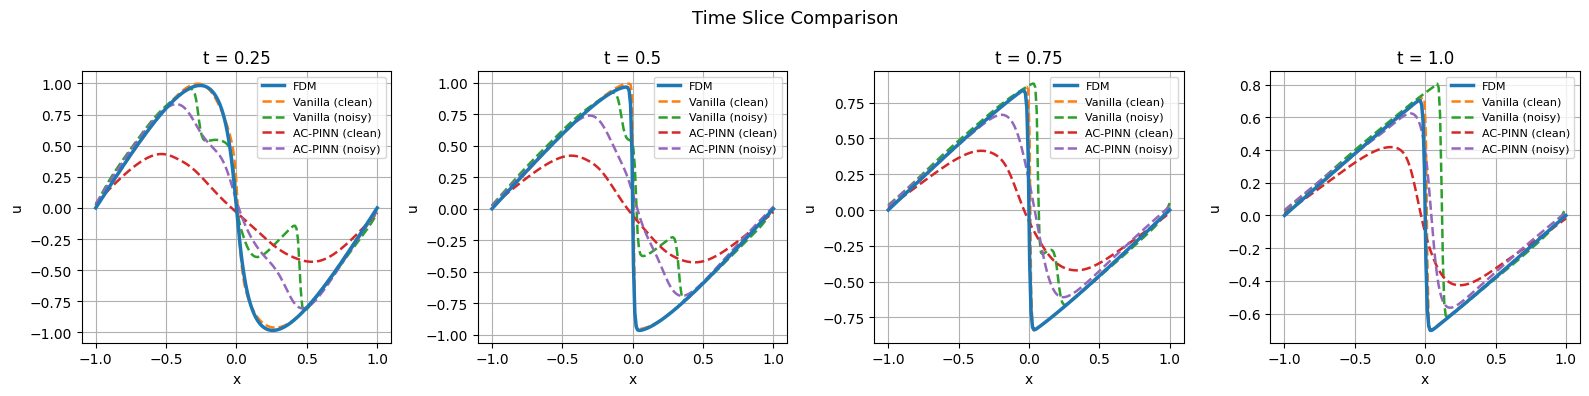

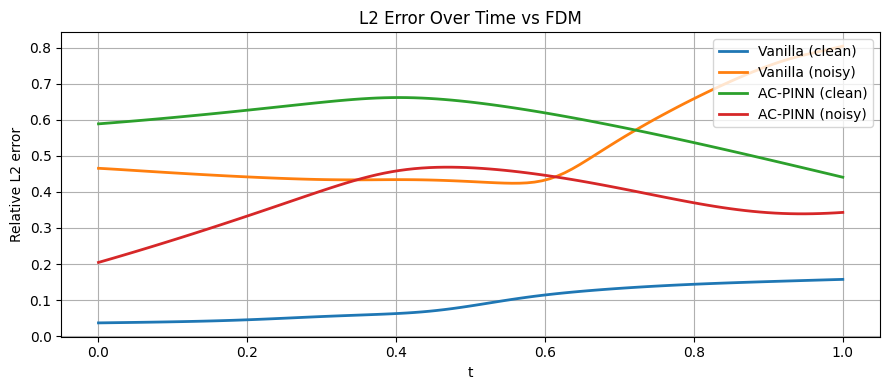

Saved: ../results/burgers/benchmark_metrics.npy
Burgers experiments complete. Results saved.


In [9]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)',  vanilla_clean)
bench.add('Vanilla (noisy)',  vanilla_noisy)
bench.add('AC-PINN (clean)',  ac_clean)
bench.add('AC-PINN (noisy)',  ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Burgers experiments complete. Results saved.')

## Section 8 - Noise Level Study (ε = 0.05, 0.1, 0.2)
AC-PINN vs Vanilla under increasing noise.

In [10]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- Noise level ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)

    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)

    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)

    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()

save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')
print('Noise study complete.')


--- Noise level ε=0.05 ---
[Epoch     0/5000] Total: 0.471505 | IC: 0.426069 | BC: 0.039813 | PDE: 0.001125


[Epoch  2500/5000] Total: 0.110126 | IC: 0.086855 | BC: 0.005927 | PDE: 0.003469



Training complete in 65.37s
[Epoch     0/5000] Stage 1/4 | Total: 0.804410 | IC: 0.643650 | BC: 0.079361 | PDE: 0.016280 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.173168 | IC: 0.002609 | BC: 0.006247 | PDE: 0.016728 | lam=(9.13,1.30,8.44)



AC-PINN training complete in 71.97s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.462441   1.971146   0.081563   0.281240
  AC-PINN ε=0.05              0.295699   0.856198   0.096070   0.179834

--- Noise level ε=0.1 ---
[Epoch     0/5000] Total: 0.520105 | IC: 0.476876 | BC: 0.025786 | PDE: 0.003489


...


AC-PINN training complete in 71.98s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.441237   1.782950   0.117372   0.268345
  AC-PINN ε=0.1               0.377973   1.240067   0.121290   0.229870

--- Noise level ε=0.2 ---
[Epoch     0/5000] Total: 0.606375 | IC: 0.403665 | BC: 0.121859 | PDE: 0.016170


[Epoch  2500/5000] Total: 0.179557 | IC: 0.082094 | BC: 0.077987 | PDE: 0.003895



Training complete in 65.24s
[Epoch     0/5000] Stage 1/4 | Total: 0.846188 | IC: 0.436278 | BC: 0.151672 | PDE: 0.051648 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.493180 | IC: 0.016798 | BC: 0.063674 | PDE: 0.030037 | lam=(7.00,1.18,10.00)



AC-PINN training complete in 71.80s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.752967   2.046708   0.210129   0.457928
  AC-PINN ε=0.2               0.367504   1.000950   0.144080   0.223503
Saved: ../results/burgers/noise_study_metrics.npy
Noise study complete.
